#### 数据筛选与排序

In [6]:
import pandas as pd
import numpy as np

csv_data = pd.read_csv('data.csv', encoding = 'gbk', parse_dates=['date'])
print(csv_data.head())

   transaction_id       date product_category product_name  quantity   price  \
0               1 2023-04-13             Home        Tools         1  423.39   
1               2 2023-12-15             Home        Decor         4  490.78   
2               3 2023-09-28      Electronics   Smartwatch         1  398.64   
3               4 2023-04-17         Clothing       Jacket         4  428.35   
4               5 2023-03-13         Clothing      T-Shirt         5  128.57   

   total_amount  customer_id region  
0        423.39           89  South  
1       1963.12          180   West  
2        398.64          200  South  
3       1713.40           61   East  
4        642.85          192   West  


In [11]:
# 筛选满足条件的数据
filtered_data = csv_data[csv_data['total_amount'] > 100]

# 筛选多条件的数据
multi_filtered_data = csv_data[(csv_data['total_amount'] > 100) & (csv_data['quantity'] < 5)]

# 各类产品的销售总额
category_total = csv_data.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)

# 各区域的平均订单金额
region_avg = csv_data.groupby('region')['total_amount'].mean()

# 每个客户的消费总额（找出高价值客户）
customer_spending = csv_data.groupby('customer_id')['total_amount'].sum().sort_values(ascending=False)

- 相关性分析


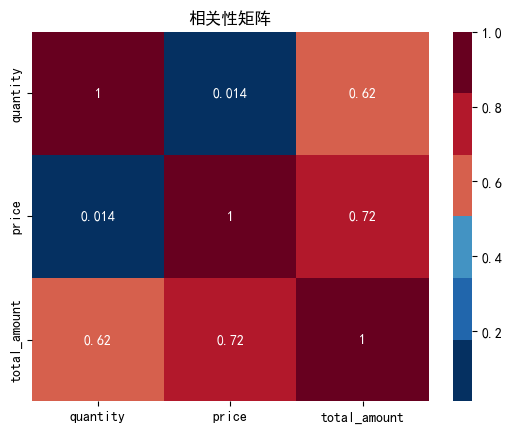

In [22]:
# 相关性分析
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

palette = [
    '#053061',
    '#2166ac',
    '#4393c3',
    '#d6604d',
    '#b2182b',
    '#67001f'
]

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 计算两列的皮尔逊相关系数和p值
corr, p_value = pearsonr(csv_data['quantity'], csv_data['total_amount'])

corr_matrix = csv_data[['quantity', 'price', 'total_amount']].corr(method='pearson')

sns.heatmap(corr_matrix, annot=True, cmap= palette )
plt.title('相关性矩阵')
plt.show()

- 时间序列分析

In [26]:
daily_sales = csv_data.groupby('date')['total_amount'].sum().reset_index()
daily_sales = daily_sales.set_index('date').sort_index()

print(daily_sales.head())

# 按月汇总销售额
monthly_sales = daily_sales.resample('ME').sum()  # 'M' 表示月末，也可以用 'MS' 表示月初
print(monthly_sales.head())

            total_amount
date                    
2023-01-01       5154.96
2023-01-02       2721.77
2023-01-03         95.01
2023-01-04       2217.18
2023-01-05       7201.73
            total_amount
date                    
2023-01-31      66784.70
2023-02-28      63086.85
2023-03-31      41285.90
2023-04-30      80670.65
2023-05-31      76648.84


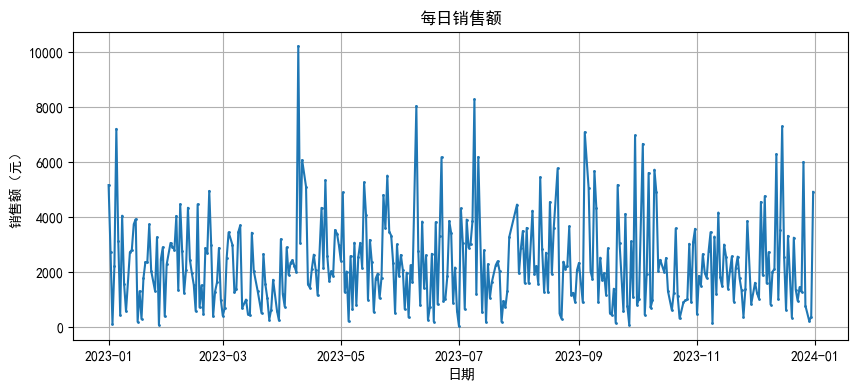

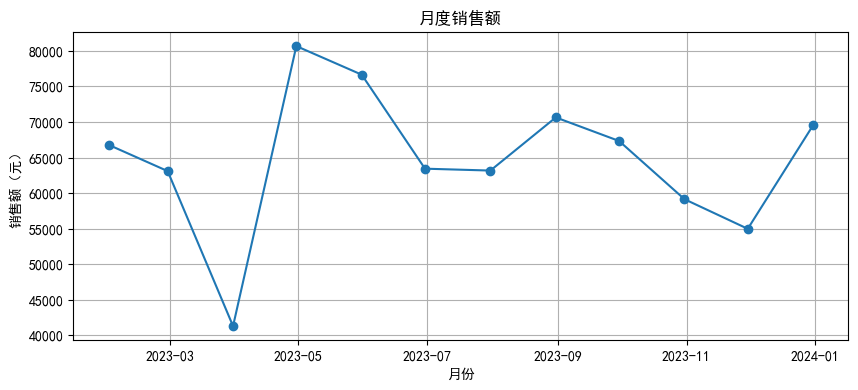

In [29]:
# 绘制每日销售额
plt.figure(figsize=(10, 4))
plt.plot(daily_sales.index,daily_sales['total_amount'], marker='.', linestyle='-', markersize=2)
plt.title('每日销售额')
plt.xlabel('日期')
plt.ylabel('销售额（元）')
plt.grid(True)
plt.show()

# 绘制月度销售额（更平滑）
plt.figure(figsize=(10, 4))
plt.plot(monthly_sales.index, monthly_sales['total_amount'], marker='o')
plt.title('月度销售额')
plt.xlabel('月份')
plt.ylabel('销售额（元）')
plt.grid(True)
plt.show()

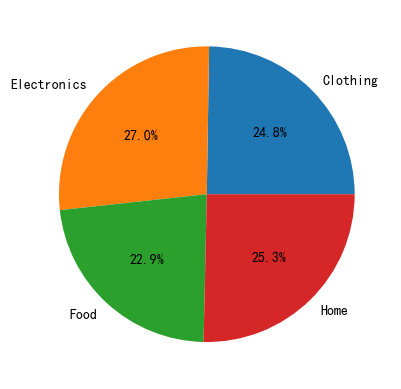

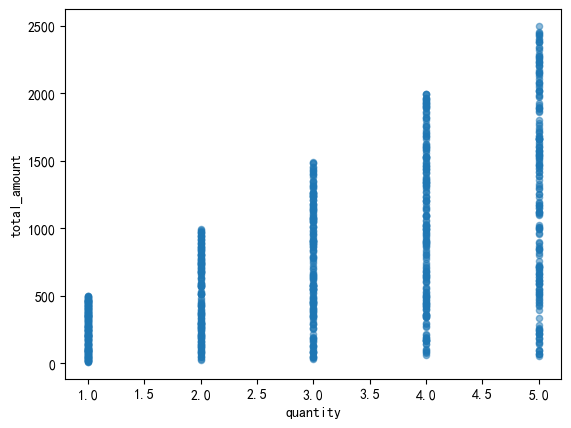

In [30]:
# 各产品类别销量占比（饼图）
category_quantity = csv_data.groupby('product_category')['quantity'].sum()
category_quantity.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

# 数量与总金额的散点图（观察是否有异常值）
csv_data.plot.scatter(x='quantity', y='total_amount', alpha=0.5)
plt.show()